In [2]:
import pandas as pd
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random 
from latent_regularizer import*

In [3]:
def draw_gmm_samples(num_samples, gmm_centers, gmm_std):
    num_gmm_centers, dimension = gmm_centers.shape
    print(num_gmm_centers, dimension)
    samples = []
    components = []
    for _ in range(num_samples):
        component = np.random.choice(range(num_gmm_centers))

        component_mean = gmm_centers[component, :]
        component_cov = torch.eye(dimension) * gmm_std

        distribution = torch.distributions.multivariate_normal.MultivariateNormal(
            loc=component_mean, covariance_matrix=component_cov)

        sample = distribution.sample((1,))
        samples.append(sample)
        components.append(component)
    samples = torch.vstack(samples)

    return samples, components

In [85]:
def generate_5_gmm_centers(num_pairs, range_start):
    import random
    unique_pairs = []
    for _ in range(num_pairs):
        num1 = random.uniform(range_start, range_start+6)
        num2 = random.uniform(range_start+6, range_start+12)
        num3 = random.uniform(range_start+12, range_start+18)
        num4 = random.uniform(range_start+18, range_start+24)
        num5 = random.uniform(range_start+30, range_start+36)
        unique_pairs.append((num1, num2, num3, num4, num5))
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

[[-6.078586 ]
 [-0.6659615]
 [ 5.917261 ]
 [14.059109 ]
 [22.435522 ]]
Standard deviation used: 2
5 1


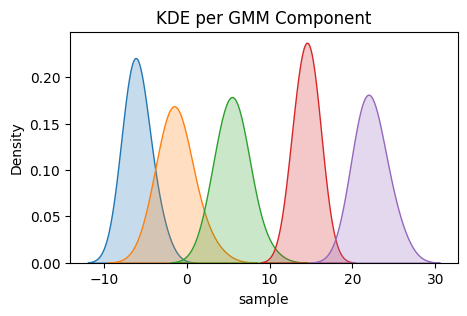

In [86]:
batch_size = 128
num_samples = 100
def gaussian_sample(num_samples):
    startpoint = random.randint(-30,0)
    gmm_centers = generate_5_gmm_centers(1, startpoint)
    print(gmm_centers.numpy())
    gmm_std=2
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    df = pd.DataFrame({'sample': data[:, 0], 'component': components})
    plt.figure(figsize=(5, 3))
    for comp_id in sorted(df['component'].unique()):
        subset = df[df['component'] == comp_id]
        sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
    plt.title("KDE per GMM Component")
    plt.show()
    return gmm_centers.numpy(), df, gmm_std
gmm_center, temp_data, gmm_std = gaussian_sample(num_samples)

[[-22.226398 ]
 [-16.322695 ]
 [ -6.6478744]
 [ -1.7875725]
 [  8.532499 ]]
Standard deviation used: 2
5 1


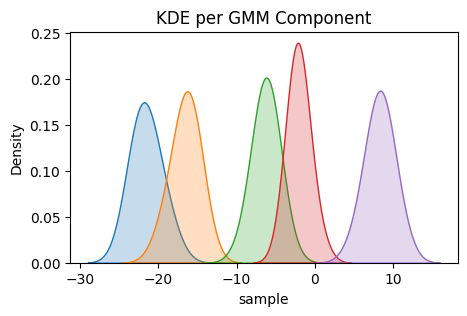

[[-7.7559457]
 [-5.2355814]
 [ 2.703965 ]
 [11.655033 ]
 [22.001598 ]]
Standard deviation used: 2
5 1


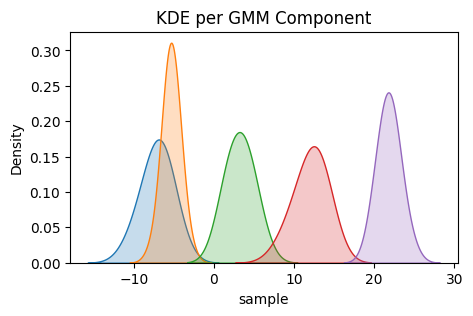

In [84]:
gmm_centers_dim1, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim2, df, gmm_std = gaussian_sample(num_samples)
df_gmm_centers_rand = pd.DataFrame(np.squeeze([gmm_centers_dim1, gmm_centers_dim2], axis=-1), columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_rand
df_gmm_centers_rand.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_rand7.csv')

[[-20.172264 ]
 [-11.293541 ]
 [ -7.1907754]
 [ -3.983031 ]
 [  9.463689 ]]
Standard deviation used: 2
5 1


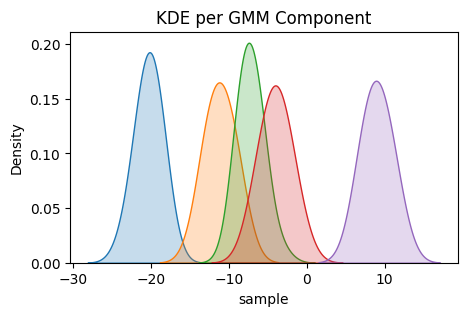

[[-22.702984 ]
 [-20.301035 ]
 [-12.269944 ]
 [ -6.0190306]
 [  6.202443 ]]
Standard deviation used: 2
5 1


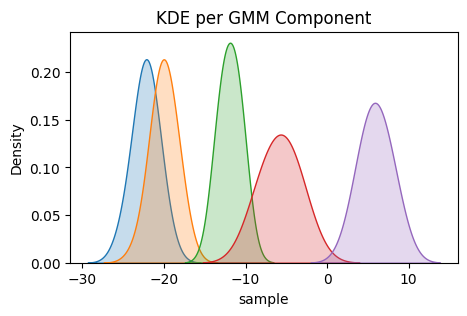

[[-11.748712 ]
 [ -8.68282  ]
 [ -0.4578471]
 [  7.194811 ]
 [ 16.704256 ]]
Standard deviation used: 2
5 1


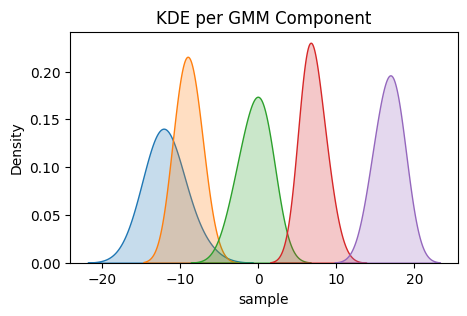

[[-12.459927 ]
 [ -6.2304373]
 [ -2.1246111]
 [  6.765072 ]
 [ 18.014086 ]]
Standard deviation used: 2
5 1


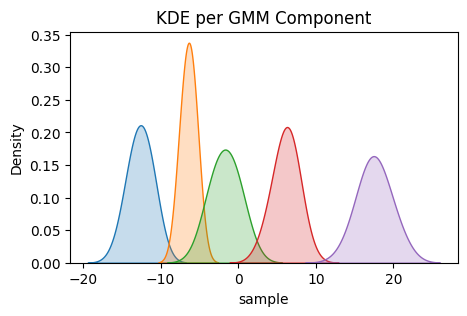

[[ 2.927976]
 [ 5.914355]
 [10.095953]
 [21.043993]
 [33.145348]]
Standard deviation used: 2
5 1


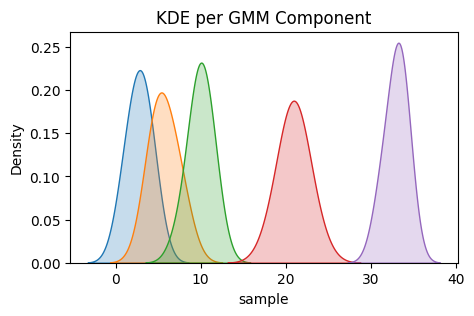

,center1,center2,center3,center4,center5
0,-20.172264,-11.293541,-7.190775,-3.983031,9.463689
1,-22.702984,-20.301035,-12.269944,-6.019031,6.202443
2,-11.748712,-8.682820,-0.457847,7.194811,16.704256
3,-12.459927,-6.230437,-2.124611,6.765072,18.014086
4,2.927976,5.914355,10.095953,21.043993,33.145348


In [90]:
latent_dim = 5  # You can change this to 10, 20, or any number you want
num_centers = 5

all_centers = [] # An empty list to store the results

for _ in range(latent_dim):
    gmm_centers, _, _ = gaussian_sample(num_samples)
    all_centers.append(gmm_centers.T)

combined_centers = np.vstack(all_centers)

column_names = [f'center{i+1}' for i in range(num_centers)]

df_gmm_centers_10 = pd.DataFrame(combined_centers, columns=column_names)

df_gmm_centers_10

In [91]:
df_gmm_centers_10.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/5_gmm_center_5dims.csv')

[[-1.9922627]
 [ 2.3115442]
 [ 9.777489 ]
 [17.319899 ]
 [24.772062 ]]
Standard deviation used: 2
5 1


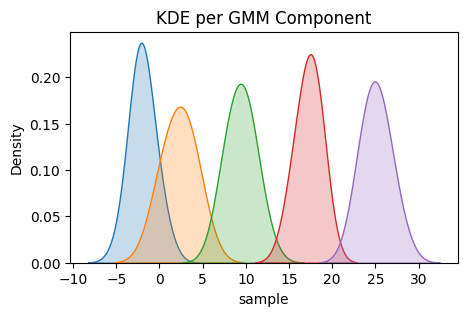

In [92]:
gmm_centers_dim2, df, gmm_std = gaussian_sample(num_samples)

In [93]:
df_gmm_centers_rand = pd.DataFrame(np.squeeze([gmm_centers_dim1, gmm_centers_dim2], axis=-1), columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_rand

,center1,center2,center3,center4,center5
0,-25.576900,-21.387688,-15.655427,-4.758278,4.710046
1,-1.992263,2.311544,9.777489,17.319899,24.772062


In [94]:
df_gmm_centers_rand.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_rand_6.csv')

In [ ]:
df_gmm_centers_box = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_box
df_gmm_centers_box.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box.csv')

In [525]:
gmm_centers_5_new = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_six.csv')
gmm_centers_5_new.values[:, 1:]

array([[-4., -2.,  0.,  2.,  4.],
       [-4., -2.,  0.,  2.,  4.]])

In [526]:
gmm_centers_5_new_np = torch.tensor(list(zip(*gmm_centers_5_new.values[:, 1:]))).float()

5 2
(128, 2)


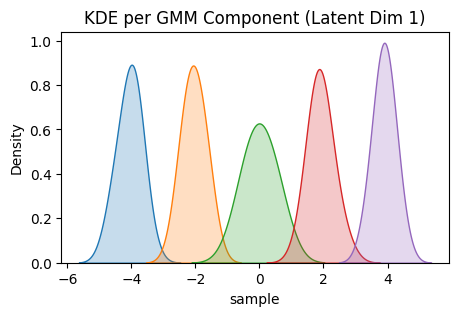

In [536]:
gmm_centers = gmm_centers_5_new_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


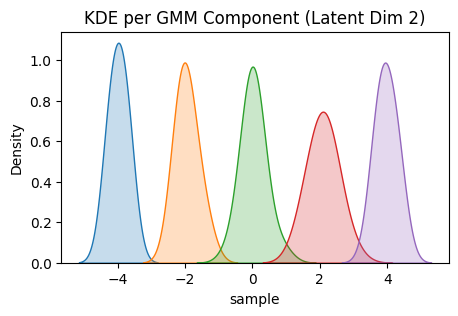

In [537]:
gmm_centers = gmm_centers_5_new_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 2)")
plt.show()

In [474]:
df_gmm_centers = pd.DataFrame(gmm_centers.T, columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_two.csv')

In [538]:
df_gmm_centers

,center1,center2,center3,center4,center5
0,-1.333333,-0.666667,0.0,0.666667,1.333333
1,-1.333333,-0.666667,0.0,0.666667,1.333333


In [126]:
center_0 = [-8, -8, 0, 8, 8]
center_1 = [-8, 8, 0, -8, 8]
df_gmm_centers_box = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_box
df_gmm_centers_box.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box_small.csv')

In [127]:
gmm_centers_5_box_np = torch.tensor(list(zip(*df_gmm_centers_box.values))).float()
gmm_centers_5_box_np

tensor([[-8., -8.],
        [-8.,  8.],
        [ 0.,  0.],
        [ 8., -8.],
        [ 8.,  8.]])

5 2
(128, 2)


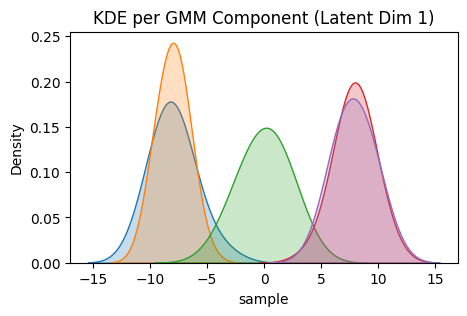

In [137]:
gmm_centers = gmm_centers_5_box_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


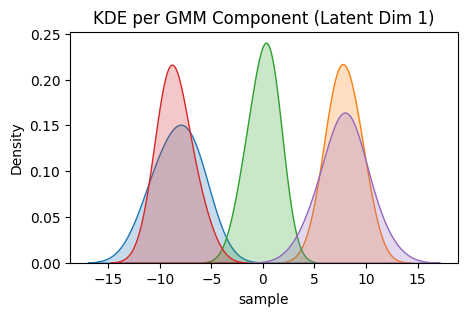

In [136]:
gmm_centers = gmm_centers_5_box_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

In [111]:
center_0 = [-20, 0, -15, 15, 20]
center_1 = [-15, -20, 15, 0, 20]
df_gmm_centers_zigzag = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_zigzag

,center1,center2,center3,center4,center5
0,-20,0,-15,15,20
1,-15,-20,15,0,20


In [112]:
df_gmm_centers_zigzag_np = torch.tensor(list(zip(*df_gmm_centers_zigzag.values))).float()
df_gmm_centers_zigzag_np

tensor([[-20., -15.],
        [  0., -20.],
        [-15.,  15.],
        [ 15.,   0.],
        [ 20.,  20.]])

5 2
(128, 2)


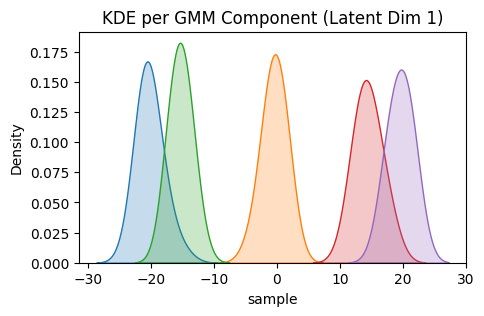

In [113]:
gmm_centers = df_gmm_centers_zigzag_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


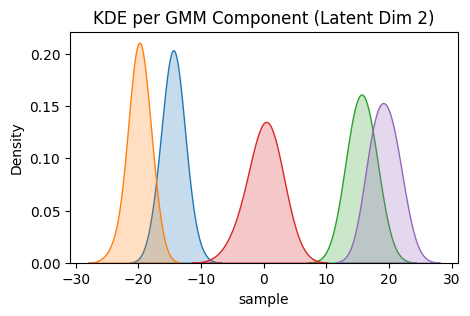

In [114]:
gmm_centers = df_gmm_centers_zigzag_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 2)")
plt.show()

In [ ]:
gmm_centers_dim1, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim2, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim3, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim4, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim5, df, gmm_std = gaussian_sample(num_samples)
df_gmm_centers_5dim = pd.DataFrame(np.squeeze([gmm_centers_dim1, gmm_centers_dim2, gmm_centers_dim3, gmm_centers_dim4, gmm_centers_dim5], axis=-1), columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_5dim

In [147]:
df_gmm_centers_5dim.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5dim_V2.csv')

In [ ]:
latent_dim = 35  # You can change this to 10, 20, or any number you want
num_centers = 5

all_centers = [] # An empty list to store the results

for _ in range(latent_dim):
    gmm_centers, _, _ = gaussian_sample(num_samples)
    all_centers.append(gmm_centers.T)

combined_centers = np.vstack(all_centers)

column_names = [f'center{i+1}' for i in range(num_centers)]

df_gmm_centers_35 = pd.DataFrame(combined_centers, columns=column_names)

df_gmm_centers_35

In [7]:
df_gmm_centers_35.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_10_dim.csv')

In [ ]:
latent_dim = 10  # You can change this to 10, 20, or any number you want
num_centers = 5

all_centers = [] # An empty list to store the results

for _ in range(latent_dim):
    gmm_centers, _, _ = gaussian_sample(num_samples)
    all_centers.append(gmm_centers.T)

combined_centers = np.vstack(all_centers)

column_names = [f'center{i+1}' for i in range(num_centers)]

df_gmm_centers_35 = pd.DataFrame(combined_centers, columns=column_names)

df_gmm_centers_35

In [25]:
def generate_10_gmm_centers(num_pairs, range_start):
    import random
    unique_pairs = []
    for _ in range(num_pairs):
        num1 = random.uniform(range_start, range_start+10)
        num2 = random.uniform(range_start+10, range_start+20)
        num3 = random.uniform(range_start+20, range_start+30)
        num4 = random.uniform(range_start+30, range_start+40)
        num5 = random.uniform(range_start+40, range_start+50)
        num6 = random.uniform(range_start+50, range_start+60)
        num7 = random.uniform(range_start+60, range_start+70)
        num8 = random.uniform(range_start+70, range_start+80)
        num9 = random.uniform(range_start+80, range_start+90)
        num10 = random.uniform(range_start+90, range_start+100)
        unique_pairs.append((num1, num2, num3, num4, num5, num6, num7, num8, num9, num10))
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

[[-24.40805  ]
 [-19.484434 ]
 [ -9.436906 ]
 [ -1.9297082]
 [ 10.907833 ]
 [ 23.079832 ]
 [ 29.607807 ]
 [ 40.377663 ]
 [ 51.986034 ]
 [ 66.349686 ]]
Standard deviation used: 3
10 1


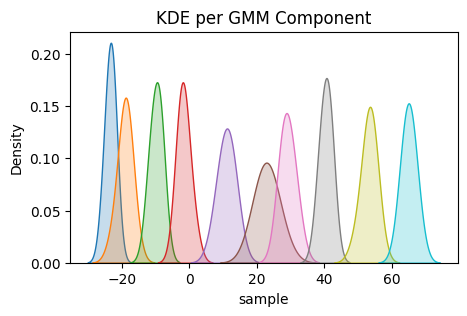

In [29]:
batch_size = 128
num_samples = 100
def gaussian_sample(num_samples):
    startpoint = random.randint(-50,0)
    gmm_centers = generate_10_gmm_centers(1, startpoint)
    print(gmm_centers.numpy())
    gmm_std=3
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    df = pd.DataFrame({'sample': data[:, 0], 'component': components})
    plt.figure(figsize=(5, 3))
    for comp_id in sorted(df['component'].unique()):
        subset = df[df['component'] == comp_id]
        sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
    plt.title("KDE per GMM Component")
    plt.show()
    return gmm_centers.numpy(), df, gmm_std
gmm_center, temp_data, gmm_std = gaussian_sample(num_samples)

[[-39.414135 ]
 [-32.097927 ]
 [-24.939257 ]
 [-17.422787 ]
 [ -3.3164287]
 [  1.1087943]
 [ 20.704134 ]
 [ 21.398699 ]
 [ 35.08963  ]
 [ 46.084602 ]]
Standard deviation used: 3
10 1


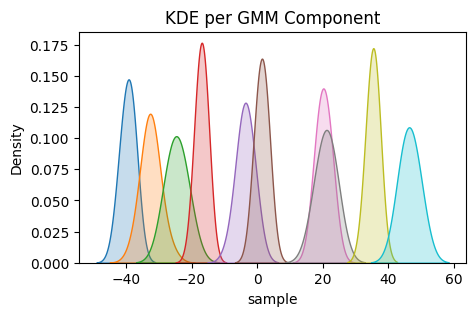

[[-14.7904415]
 [ -3.4093332]
 [  8.506271 ]
 [ 22.522062 ]
 [ 30.88815  ]
 [ 39.315685 ]
 [ 46.141598 ]
 [ 58.78094  ]
 [ 69.71874  ]
 [ 79.041466 ]]
Standard deviation used: 3
10 1


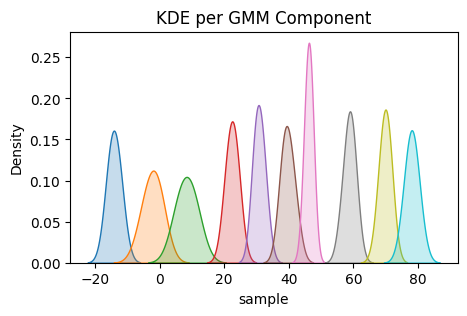

,center1,center2,center3,center4,center5,center6,center7,center8,center9,center10
0,-39.414135,-32.097927,-24.939257,-17.422787,-3.316429,1.108794,20.704134,21.398699,35.089630,46.084602
1,-14.790442,-3.409333,8.506271,22.522062,30.888149,39.315685,46.141598,58.780941,69.718742,79.041466


In [32]:
latent_dim = 2  # You can change this to 10, 20, or any number you want
num_centers = 10

all_centers = [] # An empty list to store the results

for _ in range(latent_dim):
    gmm_centers, _, _ = gaussian_sample(num_samples)
    all_centers.append(gmm_centers.T)

combined_centers = np.vstack(all_centers)

column_names = [f'center{i+1}' for i in range(num_centers)]

df_gmm_centers_10 = pd.DataFrame(combined_centers, columns=column_names)

df_gmm_centers_10

In [33]:
df_gmm_centers_10.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/10_gmm_centers_big_range.csv')